In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np

In [ ]:
df_forest = pd.read_csv('/content/Forest_to_Developed.csv')
df_forest

,OBJECTID *,Value,Count,NLCD_2014_GA_ProjectRas_Clip,NLCD_2024_GA_ProjectRas_Clip,Change_Detection,Area_SqMi,Area_Acres
0,31,31,31650,42,21,"Evergreen Forest - Developed, Open Space",10.998116,7038.786100
1,63,63,22277,42,22,"Evergreen Forest - Developed, Low Intensity",7.741075,4954.282200
2,90,90,14924,42,23,"Evergreen Forest - Developed, Medium Intensity",5.185967,3319.015600
3,112,112,81,43,21,"Mixed Forest - Developed, Open Space",0.028147,18.013954
4,128,128,8172,42,24,"Evergreen Forest - Developed, High Intensity",2.839703,1817.407800
5,144,144,68,43,22,"Mixed Forest - Developed, Low Intensity",0.023629,15.122826
6,145,145,5,41,21,"Deciduous Forest - Developed, Open Space",0.001737,1.111972
7,165,165,52,43,24,"Mixed Forest - Developed, High Intensity",0.018070,11.564514
8,166,166,37,41,24,"Evergreen Forest - Developed, High Intensity",0.012857,8.228597
9,167,167,56,43,23,"Mixed Forest - Developed, Medium Intensity",0.019460,12.454092


In [ ]:
df_ag = pd.read_csv('/content/Ag_to_Developed.csv')
df_ag

,OBJECTID *,Value,Count,NLCD_2014_GA_ProjectRas_Clip,NLCD_2024_GA_ProjectRas_Clip,Change_Detection,Area_SqMi,Area_Acres
0,30,30,4561,82,21,"Cultivated Crops - Developed, Open Space",1.584910,1014.341300
1,33,33,1568,82,22,"Cultivated Crops - Developed, Low Intensity",0.544867,348.714570
2,84,84,2246,81,21,"Pasture/Hay - Developed, Open Space",0.780467,499.498050
3,92,92,559,82,23,"Cultivated Crops - Developed, Medium Intensity",0.194248,124.318530
4,124,124,402,82,24,"Cultivated Crops - Developed, High Intensity",0.139692,89.402588
5,132,132,693,81,22,"Pasture/Hay - Developed, Low Intensity",0.240812,154.119380
6,133,133,319,81,23,"Pasture/Hay - Developed, Medium Intensity",0.110850,70.943848
7,149,149,435,81,24,"Pasture/Hay - Developed, High Intensity",0.151159,96.741608


In [ ]:
df_wetlands = pd.read_csv('/content/Wetlands_to_Developed.csv')
df_wetlands

,OBJECTID *,Value,Count,NLCD_2014_GA_ProjectRas_Clip,NLCD_2024_GA_ProjectRas_Clip,Change_Detection,Area_SqMi,Area_Acres
0,62,62,6603,90,22,"Woody Wetlands - Developed, Low Intensity",2.294488,1468.470800
1,64,64,5263,90,21,"Woody Wetlands - Developed, Open Space",1.828849,1170.462300
2,74,74,6218,90,23,"Woody Wetlands - Developed, Medium Intensity",2.160704,1382.849000
3,93,93,4875,90,24,"Woody Wetlands - Developed, High Intensity",1.694023,1084.173200
4,142,142,608,95,22,"Emergent Herbaceous Wetlands -Developed, Low I...",0.211275,135.215850
5,163,163,556,95,23,"Emergent Herbaceous Wetlands - Developed, Medi...",0.193205,123.651340
6,164,164,156,95,21,"Emergent Herbaceous Wetlands - Developed, Open...",0.054209,34.693542
7,168,168,268,95,24,"Emergent Herbaceous Wetlands - Developed, High...",0.093128,59.601727


In [ ]:
df_forest['source_type'] = 'Forest'
df_wetlands['source_type'] = 'Wetlands'
df_ag['source_type'] = 'Agriculture'

combined_df = pd.concat([df_forest, df_wetlands, df_ag], ignore_index=True)

summary = combined_df.groupby('source_type')['Area_Acres'].sum().reset_index()
summary = summary.sort_values('Area_Acres', ascending=False)

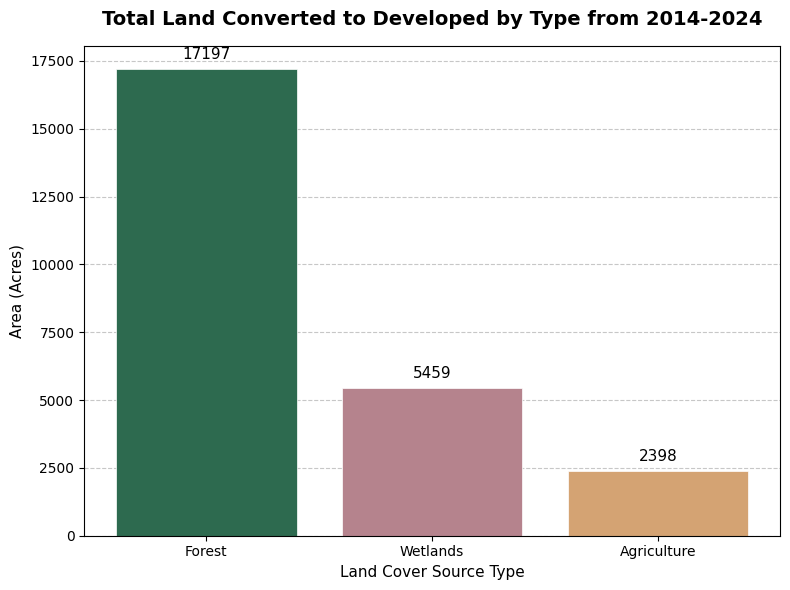

In [ ]:
fig, ax = plt.subplots(figsize=(8,6))

colors = ['#2d6a4f', '#b5838d', '#d4a373']
bars = ax.bar(summary['source_type'], summary['Area_Acres'],
              color=colors, edgecolor='white', linewidth=0.5)

ax.bar_label(bars, fmt='%.0f', padding=5, fontsize=11)

ax.set_title('Total Land Converted to Developed by Type from 2014-2024', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Land Cover Source Type', fontsize=11)
ax.set_ylabel('Area (Acres)', fontsize=11)
ax.yaxis.grid(True, linestyle='--', alpha=0.7)
ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig('total_change_by_source.png', dpi=150, bbox_inches='tight')
plt.show()

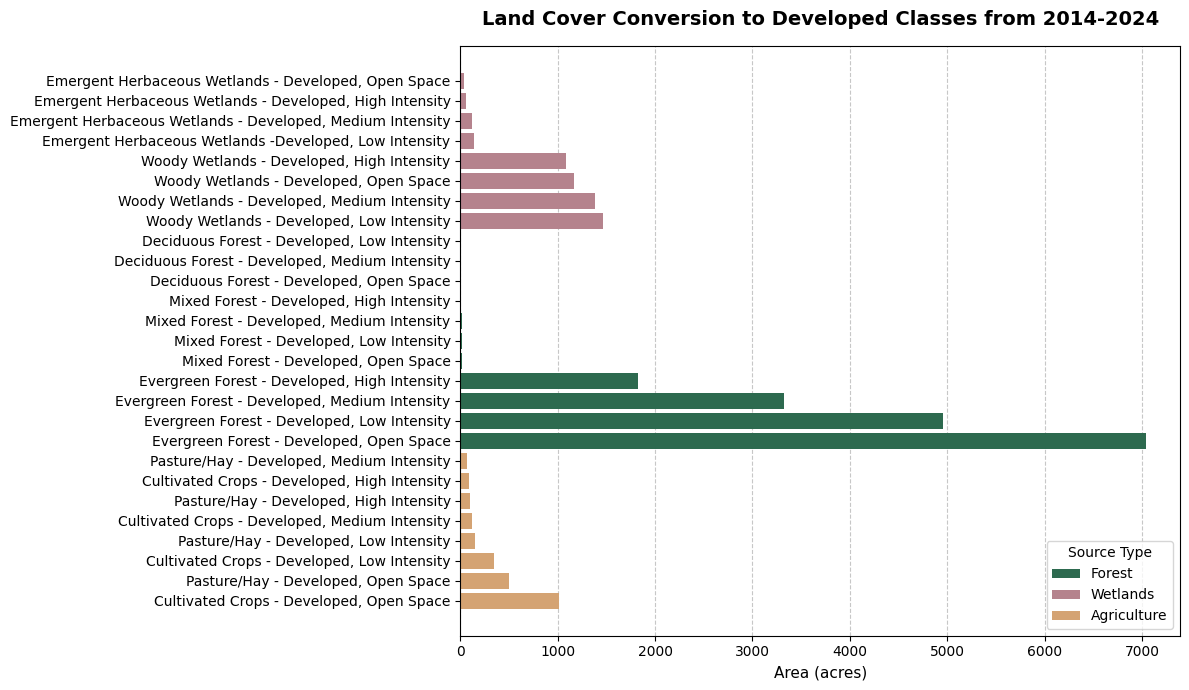

In [ ]:
fig, ax = plt.subplots(figsize=(12,7))

plot_df = combined_df.groupby(['source_type', 'Change_Detection'])['Area_Acres'].sum().reset_index()
plot_df = plot_df.sort_values(['source_type', 'Area_Acres'], ascending=[True, False])

colors = {'Forest': '#2d6a4f', 'Wetlands': '#b5838d', 'Agriculture': '#d4a373'}

bars = ax.barh(plot_df['Change_Detection'], plot_df['Area_Acres'],
               color=plot_df['source_type'].map(colors))

ax.set_title('Land Cover Conversion to Developed Classes from 2014-2024', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Area (acres)', fontsize=11)
ax.xaxis.grid(True, linestyle='--', alpha=0.7)
ax.set_axisbelow(True)

from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=v, label=k) for k, v in colors.items()]
ax.legend(handles=legend_elements, title='Source Type', loc='lower right')

plt.tight_layout()
plt.savefig('change_breakdown.png', dpi=150, bbox_inches='tight')
plt.show()